In [25]:
import torch
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from scripts.material_aware_training import material_aware_training
from scripts.config import PathConfig, MaterialAwareTrainingConfig
from flare.dataset import DatasetLoader
from scripts.flare_inference import build_flare_pipeline, run_inference, visualize_image_batch, visualize_image_buffers

In [2]:
working_dir = "/home/jsickert/adl4cv"
run_name = "high_diffusion_weights"
input_dir = "DATA/001"
train_dir = ["MVI_1814", "MVI_1810"]
output_dir = "out"
flame_path = "/home/jsickert/adl4cv/adl4cv_ws25-26_Relightable-Avatars/flare/flame/FLAME2020/generic_model.pkl"
diffusion_dir = Path("/home/jsickert/adl4cv/flare_diffusion_channels/rgbx/001")
ghostbone = True
batch_size = 2
eval_dir = ["MVI_1812"]

In [3]:
path_config = PathConfig(
    _working_dir=working_dir,
    run_name=run_name,
    input_dir=input_dir,
    output_dir=output_dir,
    flame_path=flame_path,
    diffusion_dir=diffusion_dir,
    train_dir=train_dir,
    eval_dir=eval_dir,
)

training_config1 = MaterialAwareTrainingConfig.default_stage_1_config(batch_size=batch_size, ghostbone=ghostbone)
training_config2 = MaterialAwareTrainingConfig.default_stage_2_config(batch_size=batch_size, ghostbone=ghostbone)

training_config1.weight_diffusion_albedo_regularization = 1.0
training_config1.weight_diffusion_normal_regularization = 1.0
training_config1.weight_diffusion_roughness_regularization = 1.0

training_config2.weight_diffusion_albedo_regularization = 1.0
training_config2.weight_diffusion_normal_regularization = 1.0
training_config2.weight_diffusion_roughness_regularization = 1.0

In [4]:
dataset_train = DatasetLoader(path_config, train_dir=path_config.train_dir, sample_ratio=1, pre_load=True)
dataset_val = DatasetLoader(path_config, train_dir=path_config.eval_dir, sample_ratio=1, pre_load=False)

dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=2, collate_fn=dataset_train.collate, shuffle=True, drop_last=True)
dataloader_val = torch.utils.data.DataLoader(dataset_val, batch_size=4, collate_fn=dataset_val.collate, shuffle=True, drop_last=True)

loaded 2903 views


In [5]:
diffusion_normal_losses, diffusion_albedo_losses, diffusion_roughness_losses, diffusion_irradiance_losses = material_aware_training(
    path_config=path_config,
    args1=training_config1,
    args2=training_config2,
    dataset_train=dataset_train,
    dataloader_train=dataloader_train,
)

creating the FLAME Decoder
Rasterizing: ['mask', 'position', 'normal', 'canonical_position']
Training Deformer
STAGE 1: Using positional encoding (NeRF) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [128, 128, 128, 128], 'light_mlp_dims': [64, 64]}
{'mask': 2.0, 'normal': 0.1, 'laplacian': 60.0, 'shading': 1.0, 'perceptual_loss': 0.1, 'albedo_regularization': 0.01, 'roughness_regularization': 0.01, 'white_light_regularization': 0.01, 'fresnel_coeff': 0.01, 'diffusion_normal': 1.0, 'diffusion_albedo': 1.0, 'diffusion_roughness': 1.0, 'diffusion_irradiance': 0.0, 'flame_regularization': 1.0}
Batch Size: 2


Epoch 0, Iter 1:   0%|          | 0/2 [00:00<?, ?it/s]Using /home/jsickert/.cache/torch_extensions/py39_cu116 as PyTorch extensions root...
Detected CUDA files, patching ldflags
Emitting ninja build file /home/jsickert/.cache/torch_extensions/py39_cu116/renderutils_plugin/build.ninja...
Building extension module renderutils_plugin...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)


ninja: no work to do.


Loading extension module renderutils_plugin...
Epoch 0, Iter 101:   0%|          | 0/2 [00:43<?, ?it/s, loss=0.73] 

Decaying flame regularization


...

Decaying diffusion normal regularization


Epoch 0, Iter 1000:   0%|          | 0/1 [04:39<?, ?it/s, loss=0.361]

Decaying diffusion normal regularization


Epoch 0, Iter 1451: 100%|██████████| 1/1 [06:46<00:00, 406.90s/it, loss=0.316]

TIME TAKEN (mins): 6


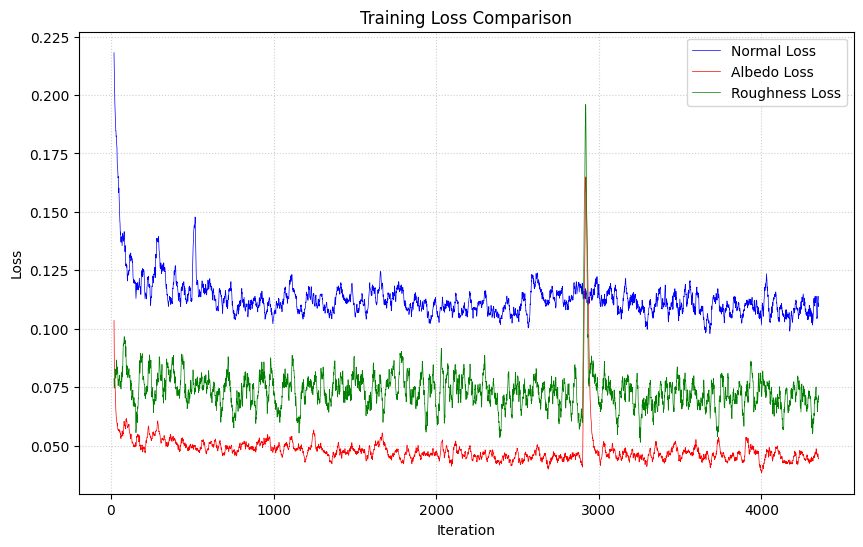

In [39]:
plt.figure(figsize=(10, 6))

diffusion_albedo_losses = pd.Series(diffusion_albedo_losses)
diffusion_albedo_losses_smooth = diffusion_albedo_losses.rolling(window=20).mean()

diffusion_normal_losses = pd.Series(diffusion_normal_losses)
diffusion_normal_losses_smooth = diffusion_normal_losses.rolling(window=20).mean()

diffusion_roughness_losses = pd.Series(diffusion_roughness_losses)
diffusion_roughness_losses_smooth = diffusion_roughness_losses.rolling(window=20).mean()


plt.plot(diffusion_normal_losses_smooth, label="Normal Loss", linewidth=0.5, color="blue")
plt.plot(diffusion_albedo_losses_smooth, label="Albedo Loss", linewidth=0.5, color="red")
plt.plot(diffusion_roughness_losses_smooth, label="Roughness Loss", linewidth=0.5, color="green")

plt.title('Training Loss Comparison')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

In [6]:
mesh, FLAMEServer, deformer_net, shader, renderer, channels_gbuffer, lgt = build_flare_pipeline(
        dataset_val=dataset_val,
        flame_path=flame_path,
        mesh_path=path_config.working_dir / output_dir / run_name / "stage_2/meshes/mesh_latest.obj",
        deformer_path=path_config.working_dir / output_dir / run_name / "stage_2/network_weights/deformer_latest.pt",
        shader_path=path_config.working_dir / output_dir / run_name / "stage_2/network_weights/shader_latest.pt",
        train_dir=train_dir,
)

creating the FLAME Decoder
STAGE 2: Using hashgrid (tinycudann) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [64, 64], 'light_mlp_dims': [64, 64]}


In [14]:
for val_views in dataloader_val:
    break

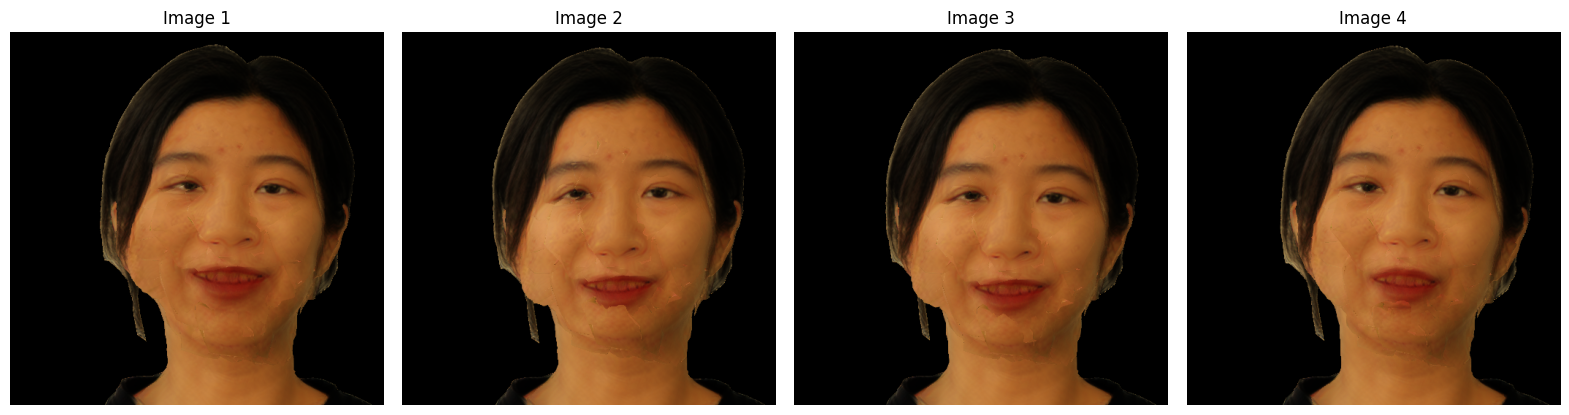

In [15]:
val_rgb_pred, val_gbuffers, val_cbuffers = run_inference(val_views, mesh, FLAMEServer, deformer_net, shader, renderer, channels_gbuffer, lgt)
visualize_image_batch(val_rgb_pred)

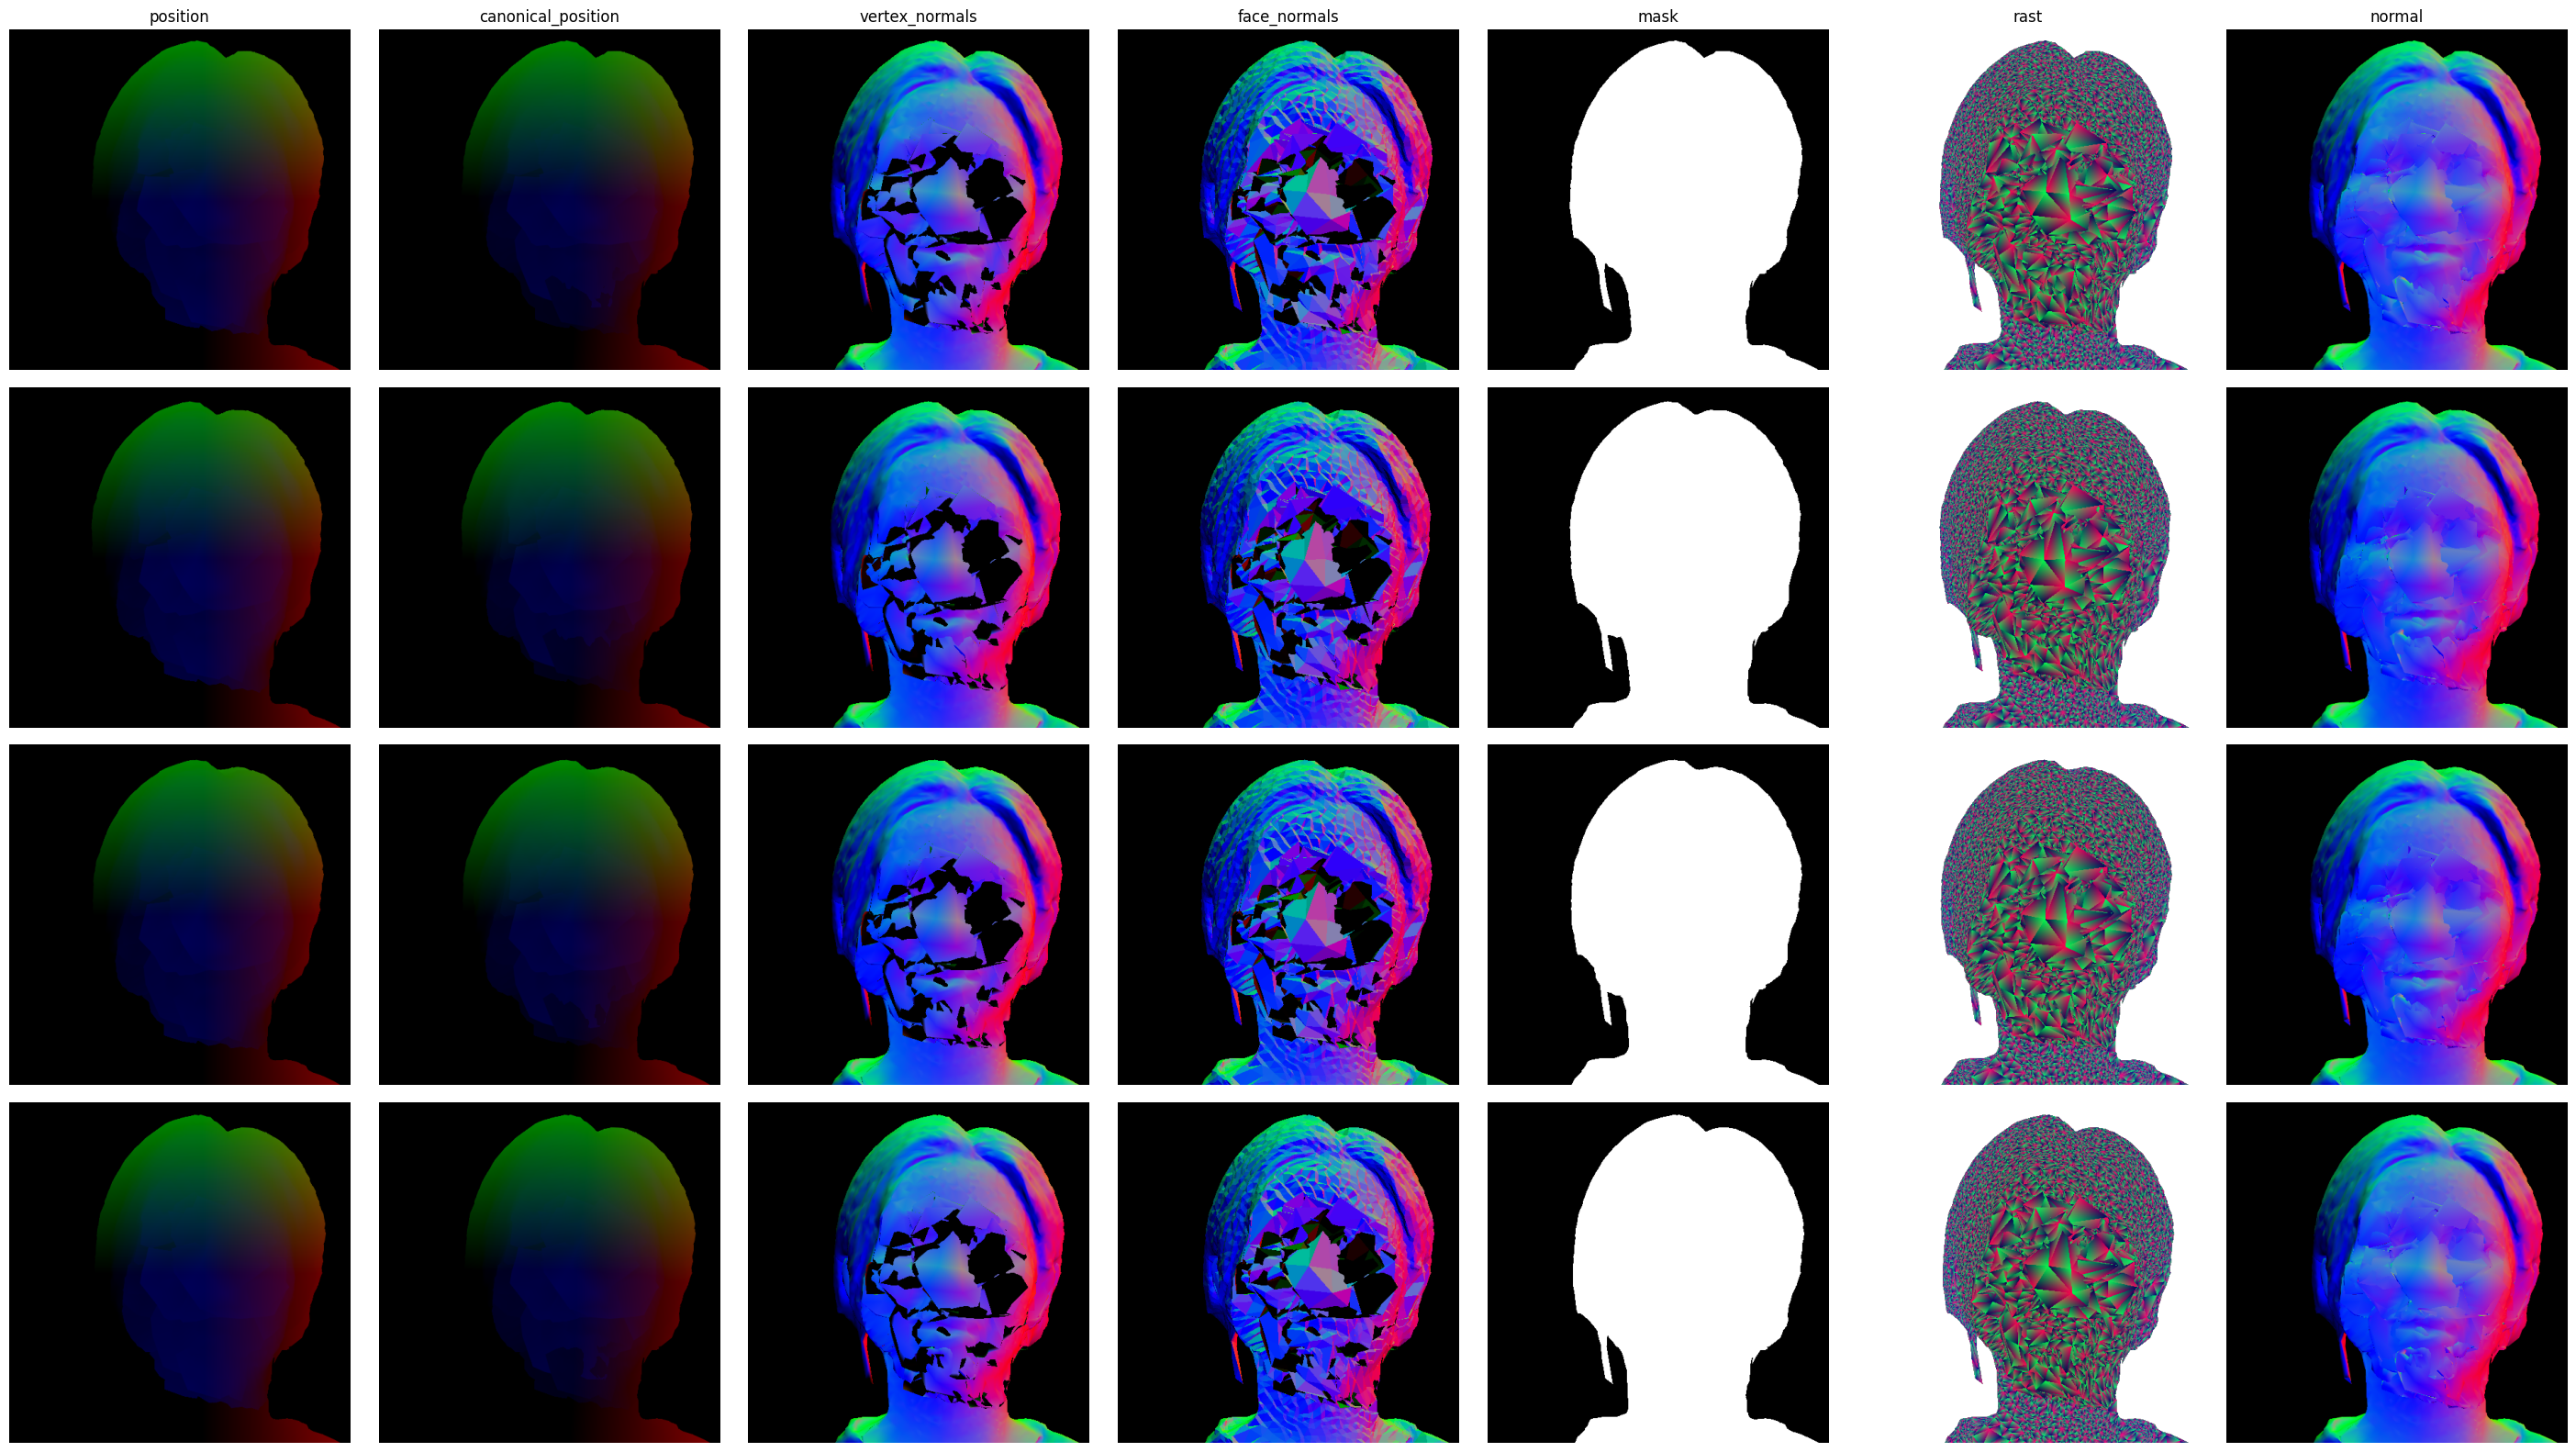

In [16]:
_gbuffers = {}
_gbuffers["position"] = val_gbuffers["position"]
_gbuffers["canonical_position"] = val_gbuffers["canonical_position"]
_gbuffers["vertex_normals"] = val_gbuffers["vertex_normals"]
_gbuffers["face_normals"] = val_gbuffers["face_normals"]
_gbuffers["mask"] = val_gbuffers["mask"]
_gbuffers["rast"] = val_gbuffers["rast"]
_gbuffers["normal"] = val_gbuffers["normal"]
visualize_image_buffers(_gbuffers)

In [17]:
for train_views in dataloader_train:
    break

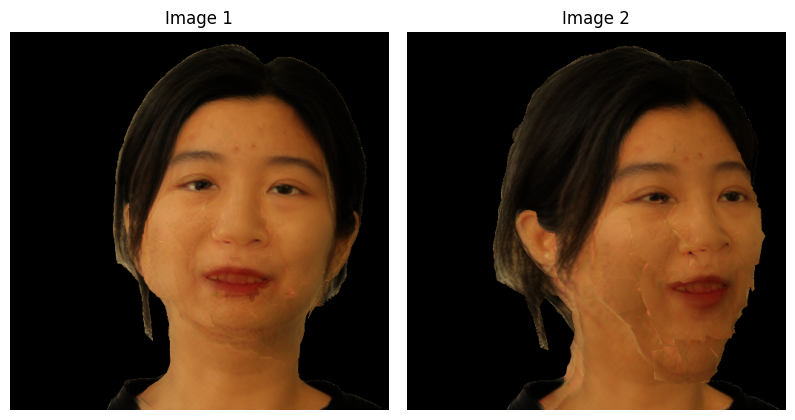

In [18]:
train_rgb_pred, train_gbuffers, train_cbuffers = run_inference(train_views, mesh, FLAMEServer, deformer_net, shader, renderer, channels_gbuffer, lgt)
visualize_image_batch(train_rgb_pred)

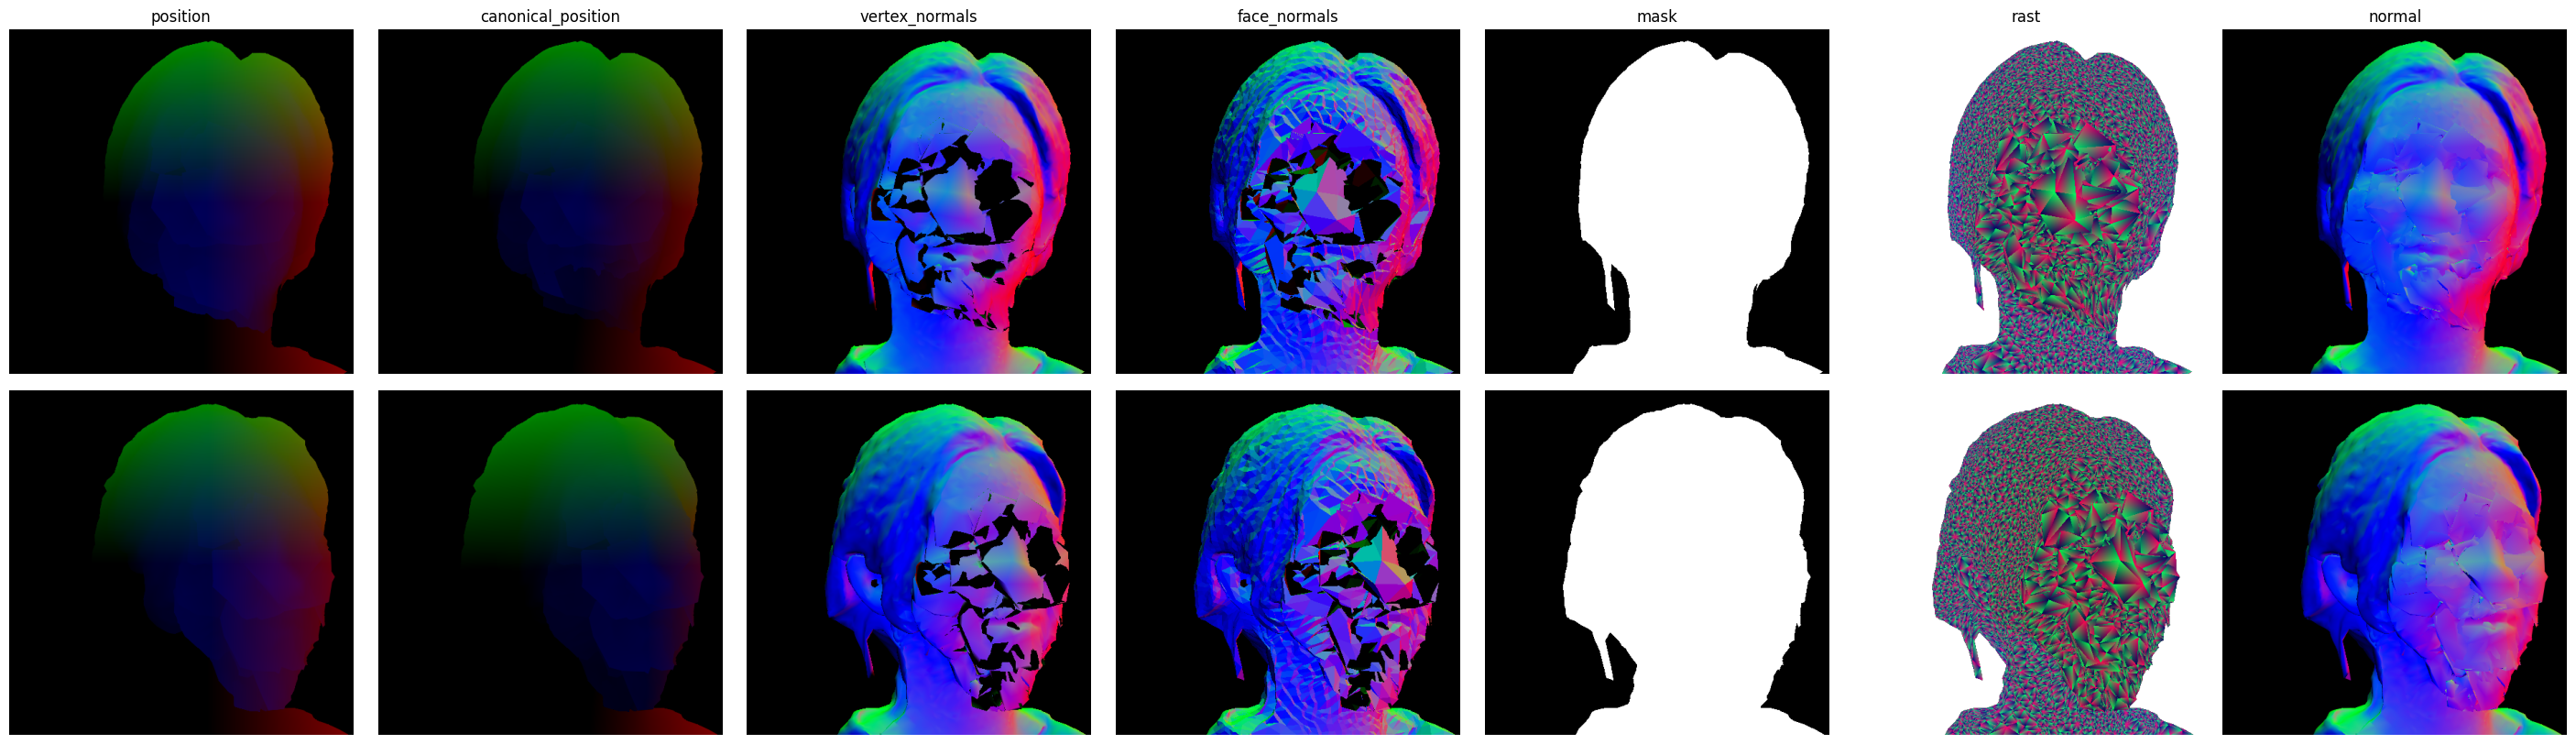

In [19]:
_gbuffers = {}
_gbuffers["position"] = train_gbuffers["position"]
_gbuffers["canonical_position"] = train_gbuffers["canonical_position"]
_gbuffers["vertex_normals"] = train_gbuffers["vertex_normals"]
_gbuffers["face_normals"] = train_gbuffers["face_normals"]
_gbuffers["mask"] = train_gbuffers["mask"]
_gbuffers["rast"] = train_gbuffers["rast"]
_gbuffers["normal"] = train_gbuffers["normal"]
visualize_image_buffers(_gbuffers)